In [1]:
import os, glob, hashlib

import pandas as pd
import geopandas as gpd

import h3
from typing import Optional, Set, Union
from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
import matplotlib.pyplot as plt

from pathlib import Path
import concurrent.futures
from tqdm.auto import tqdm

import pyarrow as pa
import pyarrow.csv as pc
import pyarrow.compute as pac
import pyarrow.parquet as pq

In [2]:
data_dirs_path = '/green-projects/project-urban_colocation_intelligence/workspace/share/data'

# **GeoJSON to H3 Cells**

## **Function to generate H3 Cells**

In [3]:
def geojson_to_h3_cells(
    geojson_path: str,
    *,
    resolution: int = 10,
    contain: str = "overlap",
    plot: bool = False,
    plot_figsize=(10, 6),
    return_gdf: bool = False,
):
    """
    Load a GeoJSON, compute H3 cells at given resolution that intersect/contain the geometry.

    Parameters
    ----------
    geojson_path : str
        Path to GeoJSON (or any vector file readable by geopandas).
    resolution : int
        H3 resolution (default 10).
    contain : str
        Passed to h3.h3shape_to_cells_experimental(..., contain=...).
        Common values: "overlap" (intersect), "center", "full".
        (Exact options depend on your h3-py version.)
    plot : bool
        If True, plots input geometry + H3 cell outlines for quick verification.
    plot_figsize : tuple
        Matplotlib figure size.
    return_gdf : bool
        If True, also returns the loaded GeoDataFrame (EPSG:4326) for reuse.

    Returns
    -------
    cells : set[str]
        Set of H3 cell IDs at `resolution`.
    (optional) gdf4326 : GeoDataFrame
        Returned if return_gdf=True.
    """
    if not os.path.exists(geojson_path):
        raise FileNotFoundError(f"File not found at: {geojson_path}")

    # ---- Load
    gdf = gpd.read_file(geojson_path)
    if gdf.empty:
        raise ValueError("GeoJSON loaded but contains no features.")

    # ---- Ensure CRS is lon/lat
    if gdf.crs is None:
        raise ValueError("Input GeoJSON has no CRS. Please set it before converting to EPSG:4326.")
    gdf4326 = gdf.to_crs("EPSG:4326")

    # ---- Union all geometries
    try:
        geom = gdf4326.geometry.union_all()
    except Exception:
        # fallback for older geopandas
        geom = gdf4326.unary_union

    if geom is None or geom.is_empty:
        raise ValueError("Unioned geometry is empty.")

    # ---- Extract polygonal geometry (handles GeometryCollection safely)
    def _extract_polygons(g):
        if g.is_empty:
            return []
        gt = g.geom_type
        if gt == "Polygon":
            return [g]
        if gt == "MultiPolygon":
            return list(g.geoms)
        if gt == "GeometryCollection":
            polys = []
            for part in g.geoms:
                polys.extend(_extract_polygons(part))
            return polys
        # ignore non-polygon types (Point/LineString/etc.)
        return []

    polys = _extract_polygons(geom)
    if not polys:
        raise TypeError(f"Unsupported/empty polygonal geometry after union. Got geom_type={geom.geom_type}")

    # ---- Convert Shapely -> H3Shape (H3 wants (lat, lng))
    def _poly_to_latlngpoly(poly: Polygon) -> h3.LatLngPoly:
        outer = [(y, x) for x, y in poly.exterior.coords]  # (lat, lng)
        holes = [[(y, x) for x, y in ring.coords] for ring in poly.interiors]
        return h3.LatLngPoly(outer, *holes)

    if len(polys) == 1:
        h3shape = _poly_to_latlngpoly(polys[0])
    else:
        h3shape = h3.LatLngMultiPoly(*[_poly_to_latlngpoly(p) for p in polys])

    # ---- Get H3 cells
    # Intersect/overlap:
    cells = set(h3.h3shape_to_cells_experimental(h3shape, resolution, contain=contain))

    # ---- Optional plot for verification
    if plot:
        # Convert H3 indexes to Shapely polygons
        cell_polys = []
        for cell in cells:
            boundary = h3.cell_to_boundary(cell)          # (lat, lng)
            pts = [(lng, lat) for lat, lng in boundary]   # shapely expects (x=lng, y=lat)
            cell_polys.append(Polygon(pts))

        gdf_cells = gpd.GeoDataFrame(
            {"h3_index": list(cells), "geometry": cell_polys},
            crs="EPSG:4326",
        )

        fig, ax = plt.subplots(figsize=plot_figsize)
        gdf4326.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5)
        gdf_cells.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.2)
        ax.set_axis_off()
        plt.show()

    return (cells, gdf4326) if return_gdf else cells

## **City of London**

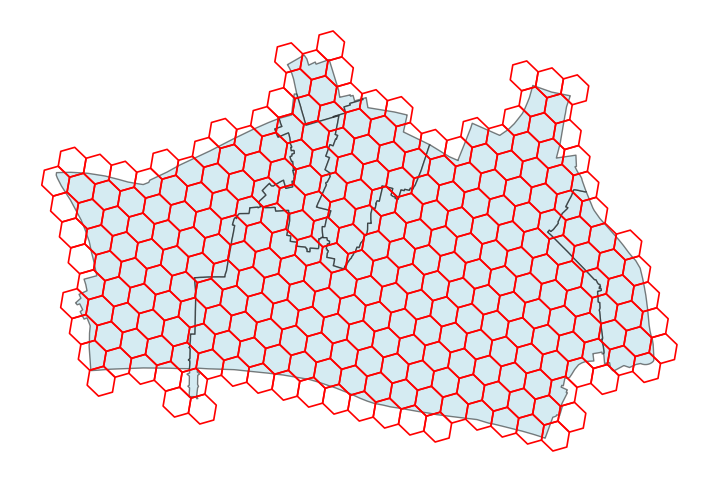

282


In [4]:
geojson_path = Path(data_dirs_path) / 'boundary' / 'London_LSOA_2021' / 'output' / 'city_of_london.geojson'

city_of_london_h3_r10 = geojson_to_h3_cells(
    geojson_path,
    resolution=10,
    contain="overlap",
    plot=True
)

print(len(city_of_london_h3_r10))

## **Canary Wharf**

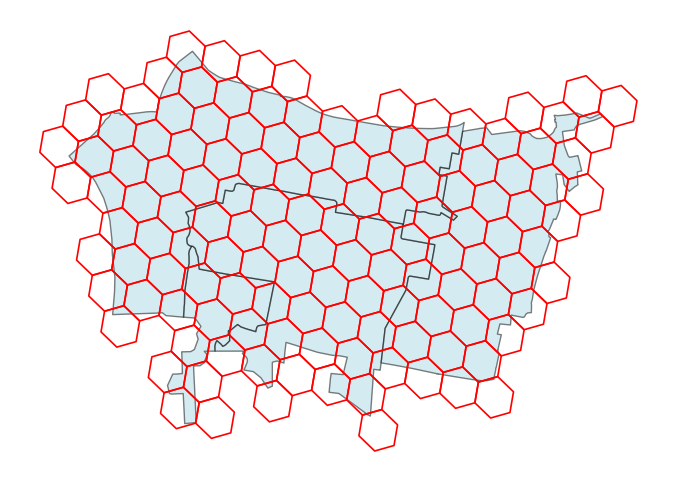

134


In [5]:
geojson_path = Path(data_dirs_path) / 'boundary' / 'London_LSOA_2021' / 'output' / 'canary_wharf.geojson'

canary_wharf_h3_r10 = geojson_to_h3_cells(
    geojson_path,
    resolution=10,
    contain="overlap",
    plot=True
)

print(len(canary_wharf_h3_r10))

# **Locomizer**

Define column names based on inspection
1. Hashed User ID
2. Latitude
3. Longitude
4. Epoch Timestamp
5. Date
6. H3 Index
7. Transport Mode

## **Functions to filer locomizer data**

In [6]:
# ---- globals used by worker processes ----
_H3_VALUESET = None
_COL_NAMES = ["user_id", "lat", "lon", "timestamp", "date", "h3_index", "transport_mode"]
_BLOCK_SIZE = None
_OUT_DIR = None

def _init_worker(h3_list, out_dir_str, block_size):
    """Runs once per process."""
    global _H3_VALUESET, _OUT_DIR, _BLOCK_SIZE
    _H3_VALUESET = pa.array(list(h3_list), type=pa.string())
    _OUT_DIR = Path(out_dir_str)
    _BLOCK_SIZE = int(block_size)

def _process_one_file(file_path: str) -> str | None:
    """Worker: stream-read one gz TSV, filter, write parquet part, return output path or None."""
    global _H3_VALUESET, _OUT_DIR, _BLOCK_SIZE, _COL_NAMES

    h = hashlib.md5(file_path.encode("utf-8")).hexdigest()
    out_path = _OUT_DIR / f"part-{h}.parquet"

    if out_path.exists() and out_path.stat().st_size > 0:
        return str(out_path)

    read_opts = pc.ReadOptions(
        column_names=_COL_NAMES,
        use_threads=True,
        block_size=_BLOCK_SIZE,
    )
    parse_opts = pc.ParseOptions(delimiter="\t")
    conv_opts  = pc.ConvertOptions(strings_can_be_null=False)

    try:
        reader = pc.open_csv(
            file_path,
            read_options=read_opts,
            parse_options=parse_opts,
            convert_options=conv_opts,
        )

        kept_batches = []
        for batch in reader:
            tm = batch.column(batch.schema.get_field_index("transport_mode"))
            h3 = batch.column(batch.schema.get_field_index("h3_index"))

            mask = pac.and_(
                pac.equal(tm, "stop"),
                pac.is_in(h3, value_set=_H3_VALUESET),
            )

            if pac.any(mask).as_py():
                kept_batches.append(batch.filter(mask))

        if not kept_batches:
            return None

        table = pa.Table.from_batches(kept_batches)

        # Cast numeric columns after filtering
        for col, t in [("lat", pa.float64()), ("lon", pa.float64()), ("timestamp", pa.float64())]:
            idx = table.schema.get_field_index(col)
            table = table.set_column(idx, col, pac.cast(table.column(col), t, safe=False))

        pq.write_table(table, out_path)
        return str(out_path)

    except Exception as e:
        err_path = _OUT_DIR / "errors.log"
        with open(err_path, "a") as f:
            f.write(f"{file_path}\t{type(e).__name__}: {e}\n")
        return None


def filter_locomizer_to_parquet(
    *,
    data_dirs_path: str,
    parquet_dir_name: str,
    h3_list,
    months=("2025-03", "2025-04"),
    max_workers=None,
    block_size=(1 << 26),
    base_parquet_dir_name="parquet_parts",
):
    """
    Scan gz TSVs under data_dirs_path/<month>/**.gz, filter rows:
        transport_mode == 'stop' AND h3_index in h3_list
    Write matching rows into parquet parts: data_dirs_path/parquet_parts/<parquet_dir_name>/
    Return a pandas DataFrame of all matched rows (loaded from parquet).
    """
    # output dirs
    parquet_dir = Path(data_dirs_path) / base_parquet_dir_name
    parquet_dir.mkdir(parents=True, exist_ok=True)
    out_dir = parquet_dir / parquet_dir_name
    out_dir.mkdir(parents=True, exist_ok=True)

    # discover files
    files = []
    for m in months:
        files.extend(glob.glob(os.path.join(data_dirs_path, m, "**", "*.gz"), recursive=True))

    print(f"Found {len(files)} .gz files")
    if not files:
        return pq.read_table(out_dir).to_pandas() if any(out_dir.glob("*.parquet")) else None

    # workers
    if max_workers is None:
        max_workers = min(6, os.cpu_count() or 2)

    written = []
    with concurrent.futures.ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_worker,
        initargs=(list(h3_list), str(out_dir), int(block_size)),
    ) as ex:
        futures = [ex.submit(_process_one_file, fp) for fp in files]

        for fut in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            p = fut.result()
            if p:
                written.append(p)

    print(f"Parquet parts written (or already existed): {len(written)}")
    print(f"Output folder: {out_dir}")

    # load dataset
    # (If there are zero matches, pq.read_table(out_dir) will error. Handle that.)
    part_files = list(out_dir.glob("part-*.parquet"))
    if not part_files:
        print("No matching rows found.")
        return None

    result_table = pq.read_table(out_dir)
    result_df = result_table.to_pandas()
    print("Final rows:", len(result_df))
    display(result_df.head())

    return result_df

## **Canary Wharf**

In [7]:
parquet_dir_name = "filtered_stop_canarywharf_parquet_parts"
h3_list = list(canary_wharf_h3_r10)

canary_wharf_filtered = filter_locomizer_to_parquet(
    data_dirs_path=data_dirs_path,
    parquet_dir_name=parquet_dir_name,
    h3_list=h3_list,
    months=("2025-03", "2025-04"),
)

Found 1837 .gz files


  0%|          | 0/1837 [00:00<?, ?it/s]

Parquet parts written (or already existed): 1837
Output folder: /green-projects/project-urban_colocation_intelligence/workspace/share/data/parquet_parts/filtered_stop_canarywharf_parquet_parts
Final rows: 2240647


,user_id,lat,lon,timestamp,date,h3_index,transport_mode
0,cb336b2ddaed10bfa8dd1457b76fe717,51.501087,-0.017264,1.742659e+09,2025-03-22,8a194ad2280ffff,stop
1,33103e1c69a23957b07e407bd1bc2f49,51.501080,-0.018290,1.742505e+09,2025-03-20,8a194ad2281ffff,stop
2,44a553d0afe5a2635904356e8eb0d5c9,51.501175,-0.018183,1.742672e+09,2025-03-22,8a194ad2281ffff,stop
3,4caeb9791989ddf13ba9ce075fb0d773,51.501270,-0.018585,1.742419e+09,2025-03-19,8a194ad2281ffff,stop
4,bc8a5ac8f8dbc732d49c33b9c9a02fee,51.501030,-0.018230,1.742522e+09,2025-03-21,8a194ad2281ffff,stop


In [11]:
output_dir = Path(data_dirs_path) / 'locomizer_filtered_output'
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_path = Path(output_dir) / 'canary_wharf_filtered.csv'

canary_wharf_filtered.to_csv(output_csv_path, index=False)
print(f"Exported to {output_csv_path}")

Exported to /green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/canary_wharf_filtered.csv


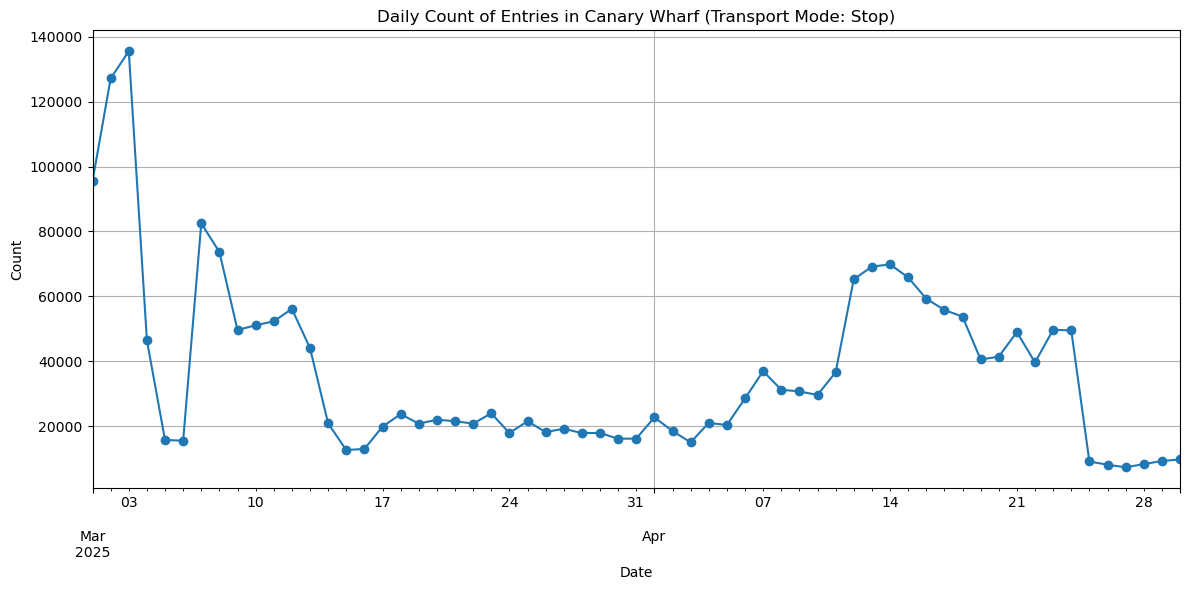

In [8]:
# Convert date column to datetime objects
canary_wharf_filtered['date'] = pd.to_datetime(canary_wharf_filtered['date'])

# Count entries per day
daily_counts = canary_wharf_filtered.groupby('date').size()

# Plotting
plt.figure(figsize=(12, 6))
daily_counts.plot(kind='line', marker='o', linestyle='-')
plt.title('Daily Count of Entries in Canary Wharf (Transport Mode: Stop)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

## **City of London**

In [9]:
parquet_dir_name = "filtered_stop_cityoflondon_parquet_parts"
h3_list = list(city_of_london_h3_r10)

city_of_london_filtered = filter_locomizer_to_parquet(
    data_dirs_path=data_dirs_path,
    parquet_dir_name=parquet_dir_name,
    h3_list=h3_list,
    months=("2025-03", "2025-04"),
)

Found 1837 .gz files


  0%|          | 0/1837 [00:00<?, ?it/s]

Parquet parts written (or already existed): 1837
Output folder: /green-projects/project-urban_colocation_intelligence/workspace/share/data/parquet_parts/filtered_stop_cityoflondon_parquet_parts
Final rows: 2420377


,user_id,lat,lon,timestamp,date,h3_index,transport_mode
0,92dd82ebd4a9b4dafdec16a2f530d141,51.50880,-0.09300,1.742355e+09,2025-03-19,8a194ad32b47fff,stop
1,4bcd6d63658ad2e8118cf918784f302f,51.50884,-0.09300,1.742822e+09,2025-03-24,8a194ad32b47fff,stop
2,1a109c7e0f9724393c95373ef23ab759,51.50883,-0.09304,1.742854e+09,2025-03-24,8a194ad32b47fff,stop
3,b022a40107ff88e58209df932edbc7e5,51.50880,-0.09300,1.742344e+09,2025-03-19,8a194ad32b47fff,stop
4,da2750a93beef424193ed3e195709692,51.50881,-0.09300,1.742808e+09,2025-03-24,8a194ad32b47fff,stop


In [12]:
output_dir = Path(data_dirs_path) / 'locomizer_filtered_output'
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_path = Path(output_dir) / 'city_of_london_filtered.csv'

city_of_london_filtered.to_csv(output_csv_path, index=False)
print(f"Exported to {output_csv_path}")

Exported to /green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/city_of_london_filtered.csv


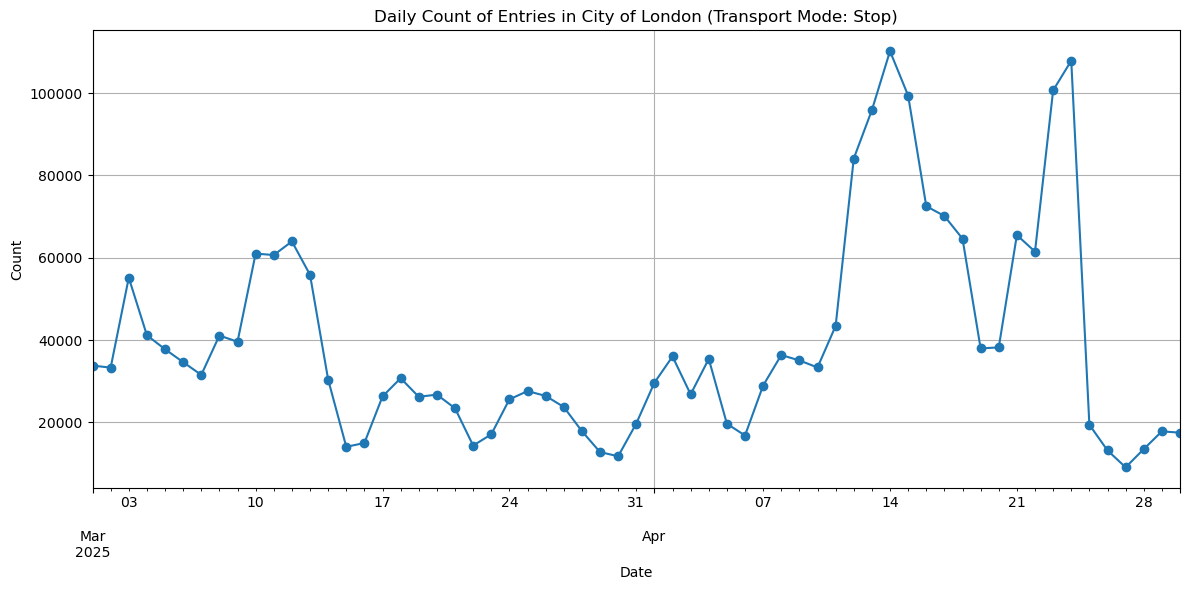

In [10]:
# Convert date column to datetime objects
city_of_london_filtered['date'] = pd.to_datetime(city_of_london_filtered['date'])

# Count entries per day
daily_counts = city_of_london_filtered.groupby('date').size()

# Plotting
plt.figure(figsize=(12, 6))
daily_counts.plot(kind='line', marker='o', linestyle='-')
plt.title('Daily Count of Entries in City of London (Transport Mode: Stop)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()